# Opinion dynamics

How can we model the evolution of opinions within a population?

E.g. https://www.uzh.ch/cmsssl/suz/dam/jcr:00000000-68cb-72db-ffff-ffffff8071db/04.02%7B_%7Dschelling%7B_%7D71.pdf

In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
import seaborn as sns

sns.set_theme()

In [4]:
# Construct a graph - nodes are agents who share their opinions across links
G = nx.complete_graph(25)

In [5]:
# Give each node an attribute to store their opinion
nx.set_node_attributes(G, 0, "op")

In [6]:
# Give each agent a random opinion as a starting configuration
for v in G.nodes(data=True):
    v[1]["op"] = random.random()

In [7]:
for v in G.nodes(data=True):
    print(f"{v[0]}: {v[1]['op']:.2}")

0: 0.27
1: 0.19
2: 0.031
3: 0.37
4: 0.31
5: 0.76
6: 0.19
7: 0.97
8: 0.23
9: 0.93
10: 0.75
11: 0.95
12: 0.26
13: 0.45
14: 0.26
15: 0.81
16: 0.71
17: 0.44
18: 0.72
19: 0.65
20: 0.41
21: 0.12
22: 0.52
23: 0.12
24: 0.17


# Bounded confidence model 

https://www.researchgate.net/profile/Frederic-Amblard/publication/312153320_Mixing_beliefs_among_interacting_agents/links/60b5ed8b4585154e5ef5cb8d/Mixing-beliefs-among-interacting-agents.pdf

ABSTRACT. We present a model of opinion dynamics where agents adjust continuous opinions on the occasion of random binary encounters whenever their difference in opinion is below a given threshold. High thresholds yield convergence of opinions towards an average opinion, but low thresholds result in several opinion clusters: members of the same cluster share the same opinion but do not adjust any more with members of other clusters.

At each time step any two randomly chosen agents meet. They re-adjust their opinion when their difference of opinion is smaller in magnitude than a threshold d.

mu is a convergence parameter that governs how much an opinion changes during an interaction.

In [8]:
d = 0.3
mu = 0.1

i = random.choice(list(G.nodes()))
j = random.choice(list(G.neighbors(i)))
print(f"Node: {i}, op={G.nodes[i]['op']:.5}; Node: {j}, op={G.nodes[j]['op']:.5}")

i_op = G.nodes[i]["op"]
j_op = G.nodes[j]["op"]
if abs(i_op - j_op) < d:
    print(
        f"{i} and {j} opinions within {d} - adjust opinions by {mu} * their difference"
    )
    G.nodes[i]["op"] = G.nodes[i]["op"] + mu * (j_op - i_op)
    G.nodes[j]["op"] = G.nodes[j]["op"] + mu * (i_op - j_op)
else:
    print(f"{i} and {j} opinions outside {d} - no opinion change")
print(f"Node: {i}, op={G.nodes[i]['op']:.5}; Node: {j}, op={G.nodes[j]['op']:.5}")


Node: 19, op=0.65256; Node: 20, op=0.412
19 and 20 opinions within 0.3 - adjust opinions by 0.1 * their difference
Node: 19, op=0.6285; Node: 20, op=0.43605


In [36]:
data = []
d = 0.3
mu = 0.75
iterations = 1000
samples = 100
G = nx.complete_graph(250)
nx.set_node_attributes(G, 0, "op")
for v in G.nodes(data=True):
    v[1]["op"] = random.random()

for iteration in range(iterations):
    for sample in range(samples):
        i = random.randrange(0, G.number_of_nodes())
        neighbours = list(G.neighbors(i))
        if len(neighbours) != 0:
            j = random.choice(neighbours)

            i_op = G.nodes[i]["op"]
            j_op = G.nodes[j]["op"]
            if abs(i_op - j_op) < d:
                G.nodes[i]["op"] = G.nodes[i]["op"] + mu * (j_op - i_op)
                G.nodes[j]["op"] = G.nodes[j]["op"] + mu * (i_op - j_op)
    data.append([G.nodes[i]["op"] for i in G.nodes])

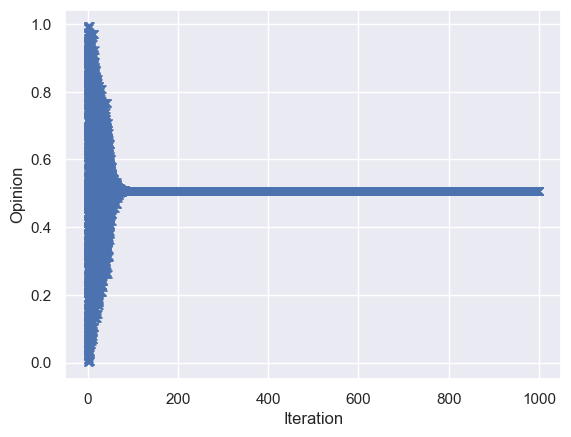

In [37]:
plt.plot(data[:], "bx")
plt.xlabel("Iteration")
plt.ylabel("Opinion")
plt.show()

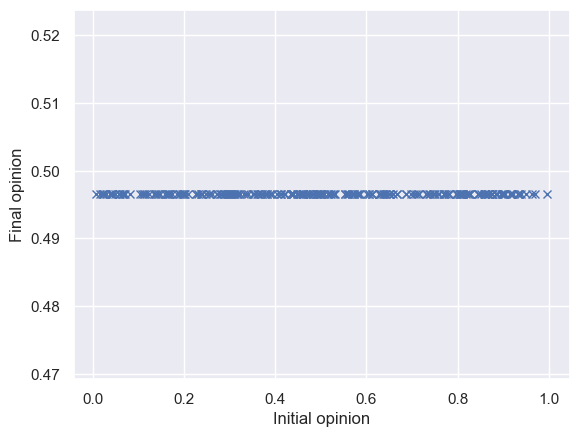

In [11]:
# How do opinions change?
plt.plot(data[0], data[-1], "x")
plt.xlabel("Initial opinion")
plt.ylabel("Final opinion")
plt.show()

# Questions

- Does the system always converge?
- Fix d = 0.3 - what is the effect of changing mu?
- Fix d = 0.3 - what is the effect of changing the size of the graph?
- How does the number of (stable) opinions relate to d?
- How might we change the model?

In [13]:
# Make code easier to run
def dw_opinions(d, mu, G, iterations=1000, samples=100):
    data = []
    nx.set_node_attributes(G, 0, "op")
    for v in G.nodes(data=True):
        v[1]["op"] = random.random()

    for iteration in range(iterations):
        for sample in range(samples):
            # i = random.randrange(0, G.number_of_nodes())
            i = random.choice(list(G.nodes()))
            neighbours = list(G.neighbors(i))
            if len(neighbours) != 0:
                j = random.choice(neighbours)

                i_op = G.nodes[i]["op"]
                j_op = G.nodes[j]["op"]
                if abs(i_op - j_op) < d:
                    G.nodes[i]["op"] = G.nodes[i]["op"] + mu * (j_op - i_op)
                    G.nodes[j]["op"] = G.nodes[j]["op"] + mu * (i_op - j_op)
        data.append([G.nodes[i]["op"] for i in G.nodes])
    return data

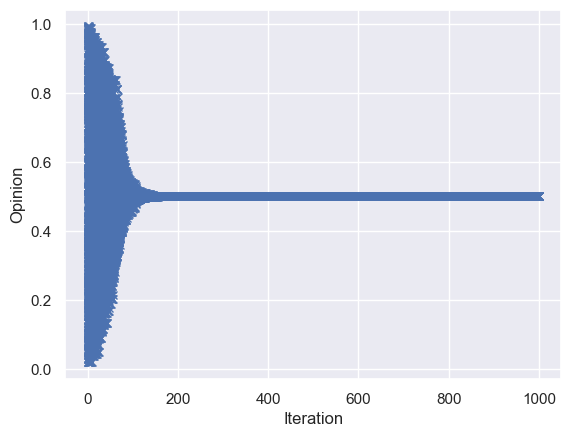

In [14]:
# How does the network structure affect the outcome?
G = nx.complete_graph(250)
data = dw_opinions(0.3, 0.1, G)
plt.plot(data[:], "bx")
plt.xlabel("Iteration")
plt.ylabel("Opinion")
plt.show()


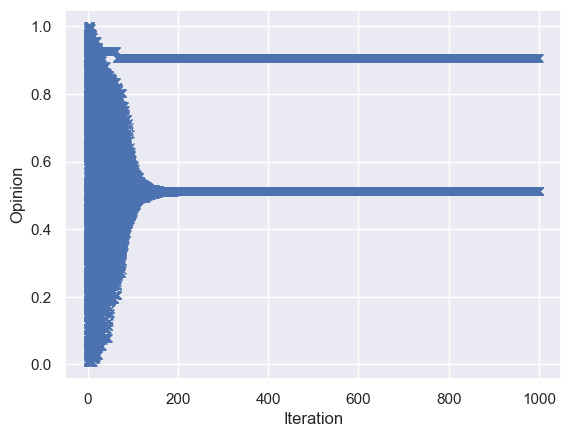

In [15]:
# How does the network structure affect the outcome?
G = nx.gnp_random_graph(250, 0.1)
data = dw_opinions(0.3, 0.1, G)
plt.plot(data[:], "bx")
plt.xlabel("Iteration")
plt.ylabel("Opinion")
plt.show()


In [ ]:
# How does the network structure affect the outcome?
G = nx.grid_2d_graph(16, 16)
data = dw_opinions(0.3, 0.1, G, iterations=10000)
plt.plot(data[:], "bx")
plt.xlabel("Iteration")
plt.ylabel("Opinion")
plt.show()

In [ ]:
plt.plot(data[0], data[-1], "x")
plt.xlabel("Initial opinion")
plt.ylabel("Final opinion")
plt.show()

In [ ]:
G = nx.convert_node_labels_to_integers(nx.read_gml("twitch_sample.gml"))
data = dw_opinions(0.3, 0.1, G)
plt.plot(data[:], "bx")
plt.xlabel("Iteration")
plt.ylabel("Opinion")
plt.show()

In [ ]:
plt.plot(data[0], data[-1], "x")
plt.xlabel("Initial opinion")
plt.ylabel("Final opinion")
plt.show()

In [ ]:
degrees = [G.degree[i] for i in G.nodes]
plt.plot(degrees, data[-1], "x")
plt.xlabel("Degree")
plt.ylabel("Final opinion")
plt.show()

In [ ]:
# https://www.math.fsu.edu/~dgalvis/journalclub/papers/02_05_2017.pdf


def hk_opinions(d, G, iterations=1000, samples=100):
    data = []
    nx.set_node_attributes(G, 0, "op")
    for v in G.nodes(data=True):
        v[1]["op"] = random.random()

    for iteration in range(iterations):
        for sample in range(samples):
            i = random.choice(list(G.nodes()))
            neighbours = list(G.neighbors(i))
            peers = [
                G.nodes[j]["op"]
                for j in neighbours
                if abs(G.nodes[i]["op"] - G.nodes[j]["op"]) < d
            ]
            if len(peers) != 0:
                G.nodes[i]["op"] = sum(peers) / len(peers)
        data.append([G.nodes[i]["op"] for i in G.nodes])
    return data

In [ ]:
G = nx.complete_graph(250)
# G = nx.convert_node_labels_to_integers(nx.read_gml("twitch_sample.gml"))
data = hk_opinions(0.2, G)
plt.plot(data[:], "bx")
plt.xlabel("Iteration")
plt.ylabel("Opinion")
plt.show()

In [ ]:
plt.plot(data[0], data[-1], "x")
plt.xlabel("Initial opinion")
plt.ylabel("Final opinion")
plt.show()

In [ ]:
G = nx.convert_node_labels_to_integers(nx.read_gml("twitch_sample.gml"))
data = hk_opinions(0.3, G)

In [ ]:
plt.plot(data[:50], "bx")
plt.xlabel("Iteration")
plt.ylabel("Opinion")
plt.show()

In [ ]:
degrees = [G.degree[i] for i in G.nodes]
plt.plot(degrees, data[-1], "x")
plt.xlabel("Degree")
plt.ylabel("Final opinion")
plt.show()

In [ ]:
# Voter model
def voter_opinions(G, iterations=1000, samples=100):
    data = []
    nx.set_node_attributes(G, 0, "op")
    for v in G.nodes(data=True):
        v[1]["op"] = random.choice([0, 1])

    for iteration in range(iterations):
        for sample in range(samples):
            i = random.choice(list(G.nodes()))
            neighbours = list(G.neighbors(i))
            if len(neighbours) != 0:
                j = random.choice(neighbours)
                G.nodes[i]["op"] = G.nodes[j]["op"]
        data.append([G.nodes[i]["op"] for i in G.nodes])
    return data

In [ ]:
# G = nx.complete_graph(250)
G = nx.convert_node_labels_to_integers(nx.read_gml("twitch_sample.gml"))
data = voter_opinions(G)

In [ ]:
plt.plot([sum(x) for x in data[:50]], "b-")
plt.xlabel("Iteration")
plt.ylabel("Number holding opinion 1")
plt.show()